# WAHL microbial and viral abundance 

In [1]:
import os
import re
import glob
from functools import reduce

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize, LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Wedge

In [11]:
MICRO_WET_RELABUND = "/Users/skoog/Desktop/Final_WATL_bins_relabund.csv"
WET_LAKE_METADATA  = "/Users/skoog/Desktop/WATL_lake_metadata.xlsx"
WET_LAKE_SALINITY  = "/Users/skoog/Desktop/WATL_lake_salinity.xlsx"
WET_BINS_TAXONOMY  = "/Users/skoog/Desktop/WATL_final_bins_taxonomy_summary.csv"
MICRO_DRY_BIN_ABUND = "/Users/skoog/Desktop/WATL24_high_quality_derep_bin_abundance_megahit_coassembly.tsv"
DRY_BAC_TAXONOMY   = "/Users/skoog/Desktop/gtdbtk.bac120.summary.tsv"
DRY_ENV            = "/Users/skoog/Desktop/WATL24_dry_season_lake_salinity_acidity_v4.xlsx"
DRY_DF_OUT         = "/Users/skoog/Desktop/dry_df.xlsx"

FINAL_VIRAL_OUT    = "/Users/skoog/Desktop/Final_WATL_wet_dry_merged_df.xlsx"

VIRAL_RPKM_COMBINED  = "/Users/skoog/Desktop/coverm_viruses_rpkm_mcf0.75_per_sample.tsv"
WATL_CATALOG_SUMMARY = "/Users/skoog/Desktop/WATL_wet_dry_viruses_uniqueIDs_virus_summary.tsv"
WATL_SAMPLE_METADATA       = "/Users/skoog/Desktop/WATL_sample_metadata_merged.xlsx"
WATL_SAMPLE_METADATA_SHEET = "WATL_metadata"   

VIRAL_DRY_TAXONOMY = "/Users/skoog/Desktop/all_checkv_quality_filtered_typical_atypical_dereplicated_viruses_from_genomad_virsorter2_virus_summary.tsv"
VIRAL_PI_WETDRY    = "/Users/skoog/Desktop/merged_df_wet_and_dry_with_df.csv"
VOTU_TAXONOMY      = "/Users/skoog/Desktop/vOTU_taxonomy_merged_df.xlsx"
VIRAL_RPKM_WET     = "/Users/skoog/Desktop/coverm_viruses_rpkm_mcf0.75_WET.tsv"
VIRAL_RPKM_DRY     = "/Users/skoog/Desktop/coverm_viruses_rpkm_mcf0.75_DRY.tsv"


In [12]:
def load_coverm_rpkm_matrix(path, strip_suffixes=None, strip_trailing=None):
    """Load a CoverM combined-matrix RPKM table.

    The new coverm_viruses_breadth.sh output is a single TSV whose first
    column is the contig name ('Contig') and whose remaining columns are
    one '<sample> RPKM' column per BAM. This replaces the old approach of
    globbing many one-sample-per-file outputs.

    Returns a wide DataFrame: first column renamed to 'contig_id', then one
    column per sample.

    strip_suffixes : substrings removed from each sample column name
                     (e.g. [" RPKM"]).
    strip_trailing : trailing tokens removed from each sample column name
                     (e.g. ["_sorted"]).
    """
    df = pd.read_csv(path, sep="\t")
    df.rename(columns={df.columns[0]: "contig_id"}, inplace=True)

    rpkm_cols = [c for c in df.columns
                 if c == "contig_id" or "RPKM" in c or "rpkm" in c]
    if len(rpkm_cols) > 1:
        df = df[rpkm_cols]

    def clean(col):
        if col == "contig_id":
            return col
        new = col
        for s in (strip_suffixes or []):
            new = new.replace(s, "")
        new = new.strip()
        for t in (strip_trailing or []):
            if new.endswith(t):
                new = new[: -len(t)]
        return new.strip()

    df.columns = [clean(c) for c in df.columns]
    return df


In [13]:
#microbial MAG abundance 

import pandas as pd

abundance_file = MICRO_WET_RELABUND
abundance_df = pd.read_csv(abundance_file)

abundance_cols = [col for col in abundance_df.columns if col != "Metagenome"]

abundance_long = abundance_df.melt(
    id_vars="Metagenome",
    value_vars=abundance_cols,
    var_name="Bin",
    value_name="Abundance"
)


wet_ph_aw = pd.read_excel(WET_LAKE_METADATA)
wet_salinity = pd.read_excel(WET_LAKE_SALINITY)

fourth_col_name = wet_ph_aw.columns[3]
wet_ph_aw = wet_ph_aw.rename(columns={fourth_col_name: "name_full"})
first_col_name = wet_ph_aw.columns[0]
wet_ph_aw = wet_ph_aw.rename(columns={first_col_name: "sample"})

wet_metadata = pd.merge(
    wet_ph_aw,
    wet_salinity,
    on="name_full",
    how="left" 
)

wet_metadata.rename(columns={"sample": "Metagenome"}, inplace=True)
wet_metadata = wet_metadata.drop_duplicates()


wet_season_merged_df = pd.merge(abundance_long, wet_metadata, on="Metagenome", how="left")


taxonomy_file = WET_BINS_TAXONOMY
taxonomy_df = pd.read_csv(taxonomy_file)

taxonomy_df.rename(columns={taxonomy_df.columns[0]: "Bin"}, inplace=True)

wet_season_merged_taxonomy_df = pd.merge(wet_season_merged_df, taxonomy_df, on="Bin", how="left")

wet_season_merged_taxonomy_df = wet_season_merged_taxonomy_df[
    wet_season_merged_taxonomy_df["Metagenome"].str.contains("brine|brins", case=False, na=False)
]

columns_to_keep = [
    "Bin",
    "Abundance",
    "name_full",
    "pH",
    "Salinity",
    "drep_winner",
    "gtdb_classification"
]

wet_season_merged_taxonomy_df = wet_season_merged_taxonomy_df[columns_to_keep]


wet_season_merged_taxonomy_df_avg_abundance = (
    wet_season_merged_taxonomy_df
    .groupby(["name_full", "Bin"], as_index=False)
    .agg({
        "Abundance": "mean",
        "pH": "first",  
        "Salinity": "first",  
        "drep_winner": "first",
        "gtdb_classification": "first"
    })
)

taxonomy_levels = ['domain', 'phylum', 'class', 'order', 'family', 'genus', 'species']

taxonomy_split = wet_season_merged_taxonomy_df_avg_abundance["gtdb_classification"].str.split(";", expand=True)

taxonomy_split.columns = taxonomy_levels

wet_season_merged_taxonomy_df_avg_abundance = pd.concat([wet_season_merged_taxonomy_df_avg_abundance, taxonomy_split], axis=1)

for col in taxonomy_levels:
    wet_season_merged_taxonomy_df_avg_abundance[col] = wet_season_merged_taxonomy_df_avg_abundance[col].str[3:]  

taxonomy_levels = ["domain", "phylum", "class", "order", "family", "genus", "species"]


def fill_unclassified(row):
    last_classified = None
    for col in taxonomy_levels:
        val = row[col]
        if pd.notna(val) and val.strip() != "":
            last_classified = val
        else:
            row[col] = f"Unclassified {last_classified}" if last_classified else "Unclassified"
    return row

wet_df = wet_season_merged_taxonomy_df_avg_abundance.apply(fill_unclassified, axis=1)

wet_df["Season"] = "Wet"


display(wet_df)

,name_full,Bin,Abundance,pH,Salinity,drep_winner,gtdb_classification,domain,phylum,class,order,family,genus,species,Season
0,Anderson Lake,220804_BK_C1_DNA_brine_C_bin.13,0.000767,7.58,145.0,220804_BK_C1_DNA_brine_C_bin.13,d__Archaea;p__Halobacteriota;c__Halobacteria;o...,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halobaculum,Unclassified Halobaculum,Wet
1,Anderson Lake,220804_BK_C1_DNA_brine_C_bin.14,0.000445,7.58,145.0,220804_BK_C1_DNA_brine_C_bin.14,d__Archaea;p__Halobacteriota;c__Halobacteria;o...,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Halobacteriaceae,Unclassified Halobacteriaceae,Unclassified Halobacteriaceae,Wet
2,Anderson Lake,220804_BK_C1_DNA_brine_C_bin.15,0.000440,7.58,145.0,220804_BK_C1_DNA_brine_C_bin.15,d__Archaea;p__Halobacteriota;c__Halobacteria;o...,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halobaculum,Unclassified Halobaculum,Wet
3,Anderson Lake,220804_BK_C1_DNA_brine_C_bin.17,0.000674,7.58,145.0,220804_BK_C1_DNA_brine_C_bin.17,d__Archaea;p__Halobacteriota;c__Halobacteria;o...,Archaea,Halobacteriota,Halobacteria,Halobacteriales,Haloferacaceae,Halonotius,Unclassified Halonotius,Wet
4,Anderson Lake,220804_BK_C1_DNA_brine_C_bin.25,0.000208,7.58,145.0,220804_BK_C1_DNA_brine_C_bin.25,d__Bacteria;p__Bacteroidota;c__Rhodothermia;o_...,Bacteria,Bacteroidota,Rhodothermia,Rhodothermales,Salinibacteraceae,Salinibacter,Unclassified Salinibacter,Wet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20911,Yellowdine Lake,220817_LF_B8_DNA_brine_C_bin.22,0.000452,8.37,52.0,220817_LF_B8_DNA_brine_C_bin.22,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Halieaceae,Luminiphilus,Unclassified Luminiphilus,Wet
20912,Yellowdine Lake,220817_LF_B8_DNA_brine_C_bin.23,0.000341,8.37,52.0,220817_LF_B8_DNA_brine_C_bin.23,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Litoricolaceae,HIMB30,Unclassified HIMB30,Wet
20913,Yellowdine Lake,220817_LF_B8_DNA_brine_C_bin.3,0.000371,8.37,52.0,220817_LF_B8_DNA_brine_C_bin.3,d__Bacteria;p__Pseudomonadota;c__Alphaproteoba...,Bacteria,Pseudomonadota,Alphaproteobacteria,UBA8317,UBA8317,UBA8317,Unclassified UBA8317,Wet
20914,Yellowdine Lake,220817_LF_B8_DNA_brine_C_bin.4,0.001369,8.37,52.0,220817_LF_B8_DNA_brine_C_bin.4,d__Bacteria;p__Deinococcota;c__Deinococci;o__D...,Bacteria,Deinococcota,Deinococci,Deinococcales,Trueperaceae,SLSQ01,Unclassified SLSQ01,Wet


In [14]:
# number of unique bins
num_unique_bins = wet_df["Bin"].nunique()
print("Number of unique bins:", num_unique_bins)


Number of unique bins: 581


In [15]:
file_path = MICRO_DRY_BIN_ABUND
df = pd.read_csv(file_path, sep="\t")

rpkm_cols = [col for col in df.columns if "RPKM" in col]
df_rpkm = df[["Genome"] + rpkm_cols] if "Genome" in df.columns else df.iloc[:, [0] + [df.columns.get_loc(col) for col in rpkm_cols]]

df_long = df_rpkm.melt(id_vars=df_rpkm.columns[0], 
                       var_name="Sample", 
                       value_name="RPKM")

df_long["Sample"] = df_long["Sample"].str.replace(" RPKM", "", regex=False)

df_long["Relative_Abundance"] = df_long.groupby("Sample")["RPKM"].transform(lambda x: x / x.sum() * 100)
df_long.rename(columns={df_long.columns[0]: "Bin"}, inplace=True)

tax_file = DRY_BAC_TAXONOMY
df_tax = pd.read_csv(tax_file, sep="\t")

tax_split = df_tax["classification"].str.split(";", expand=True)
tax_split.columns = ["domain", "phylum", "class", "order", "family", "genus", "species"]

for col in tax_split.columns:
    tax_split[col] = tax_split[col].str.replace(r"^[a-z]__*", "", regex=True).replace("", pd.NA)

df_tax_clean = pd.concat([df_tax["user_genome"], tax_split], axis=1)
df_tax_clean.rename(columns={df_tax_clean.columns[0]: "Bin"}, inplace=True)

taxonomy_levels = ["domain", "phylum", "class", "order", "family", "genus", "species"]

for i, level in enumerate(taxonomy_levels):
    for idx, row in df_tax_clean.iterrows():
        if pd.isna(row[level]) or row[level] == "":
            # Look up to more general ranks
            for j in range(i - 1, -1, -1):
                higher_rank = taxonomy_levels[j]
                higher_val = row[higher_rank]
                if pd.notna(higher_val) and higher_val != "":
                    df_tax_clean.at[idx, level] = f"Unclassified {higher_val}"
                    break


import re

def simplify_unclassified(value):
    if isinstance(value, str) and "Unclassified" in value:
        # Remove multiple "Unclassified " prefixes and keep only one
        return re.sub(r'^(Unclassified\s+)+', 'Unclassified ', value).strip()
    return value

taxonomy_cols = ["domain", "phylum", "class", "order", "family", "genus", "species"]

for col in taxonomy_cols:
    df_tax_clean[col] = df_tax_clean[col].apply(simplify_unclassified)

dry_season_merged_df = pd.merge(df_long, df_tax_clean, on="Bin", how="left")

dry_season_merged_df["Sample"] = (
    dry_season_merged_df["Sample"]
    .str.replace("_map_sorted_megahit_coassembly", "", regex=False)
    .str.replace("_map_sorted", "", regex=False)   # in case some have only this part
    .str.strip()
)

dry_salinity_acidity = pd.read_excel(DRY_ENV)
dry_salinity_acidity = dry_salinity_acidity.rename(columns={"Sample_ID": "Sample"})


import pandas as pd

merged_dry = pd.merge(
    dry_season_merged_df,
    dry_salinity_acidity,
    on="Sample",
    how="left",         
    suffixes=("", "_meta")  
)

merged_dry_dna = merged_dry[merged_dry["Sample_Type"] == "DNA"].copy()


grouped_avg = (
    merged_dry_dna
    .groupby(["Bin", "Lake_name"], as_index=False)
    .agg({"Relative_Abundance": "mean"})
    .rename(columns={"Relative_Abundance": "Abundance"})
)

merged_avg = pd.merge(
    merged_dry_dna.drop(columns=["Relative_Abundance"]),
    grouped_avg,
    on=["Bin", "Lake_name"],
    how="inner"
)

merged_avg = merged_avg.drop_duplicates(subset=["Bin", "Lake_name"])





merged_avg["Season"] = "Dry"
merged_avg["name_full"] = merged_avg["Lake_name"] + " (dry season)"

dry_df = merged_avg

output_path = DRY_DF_OUT
dry_df.to_excel(output_path, index=False, engine="openpyxl")

In [16]:
wet_and_dry_merged_df = pd.concat([dry_df, wet_df], join="inner", ignore_index=True)
display(wet_and_dry_merged_df)

,Bin,domain,phylum,class,order,family,genus,species,pH,Salinity,Abundance,Season,name_full
0,unmapped,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.93,315.0,NaN,Dry,Yellow Lake (dry season)
1,bin.168,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhodospirillales_A,Casp-alpha2,Unclassified Casp-alpha2,Unclassified Casp-alpha2,2.93,315.0,0.311563,Dry,Yellow Lake (dry season)
2,bin.266,Bacteria,Actinomycetota,Actinomycetia,Actinomycetales,Microbacteriaceae,Pontimonas,Unclassified Pontimonas,2.93,315.0,0.214677,Dry,Yellow Lake (dry season)
3,bin.4,Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales,Devosiaceae,Devosia,Unclassified Devosia,2.93,315.0,0.353550,Dry,Yellow Lake (dry season)
4,bin.151,Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae,Tsuneonella,Tsuneonella sp007065885,2.93,315.0,0.412447,Dry,Yellow Lake (dry season)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21756,220817_LF_B8_DNA_brine_C_bin.22,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Halieaceae,Luminiphilus,Unclassified Luminiphilus,8.37,52.0,0.000452,Wet,Yellowdine Lake
21757,220817_LF_B8_DNA_brine_C_bin.23,Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales,Litoricolaceae,HIMB30,Unclassified HIMB30,8.37,52.0,0.000341,Wet,Yellowdine Lake
21758,220817_LF_B8_DNA_brine_C_bin.3,Bacteria,Pseudomonadota,Alphaproteobacteria,UBA8317,UBA8317,UBA8317,Unclassified UBA8317,8.37,52.0,0.000371,Wet,Yellowdine Lake
21759,220817_LF_B8_DNA_brine_C_bin.4,Bacteria,Deinococcota,Deinococci,Deinococcales,Trueperaceae,SLSQ01,Unclassified SLSQ01,8.37,52.0,0.001369,Wet,Yellowdine Lake


In [17]:
# number of unique bins
num_unique_bins = wet_and_dry_merged_df["phylum"].nunique()
print("Number of unique phylum:", num_unique_bins)


Number of unique phylum: 29


/var/folders/cy/8q3xnh8d03z1c1c21dpxp6380000gn/T/ipykernel_92534/4211439966.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


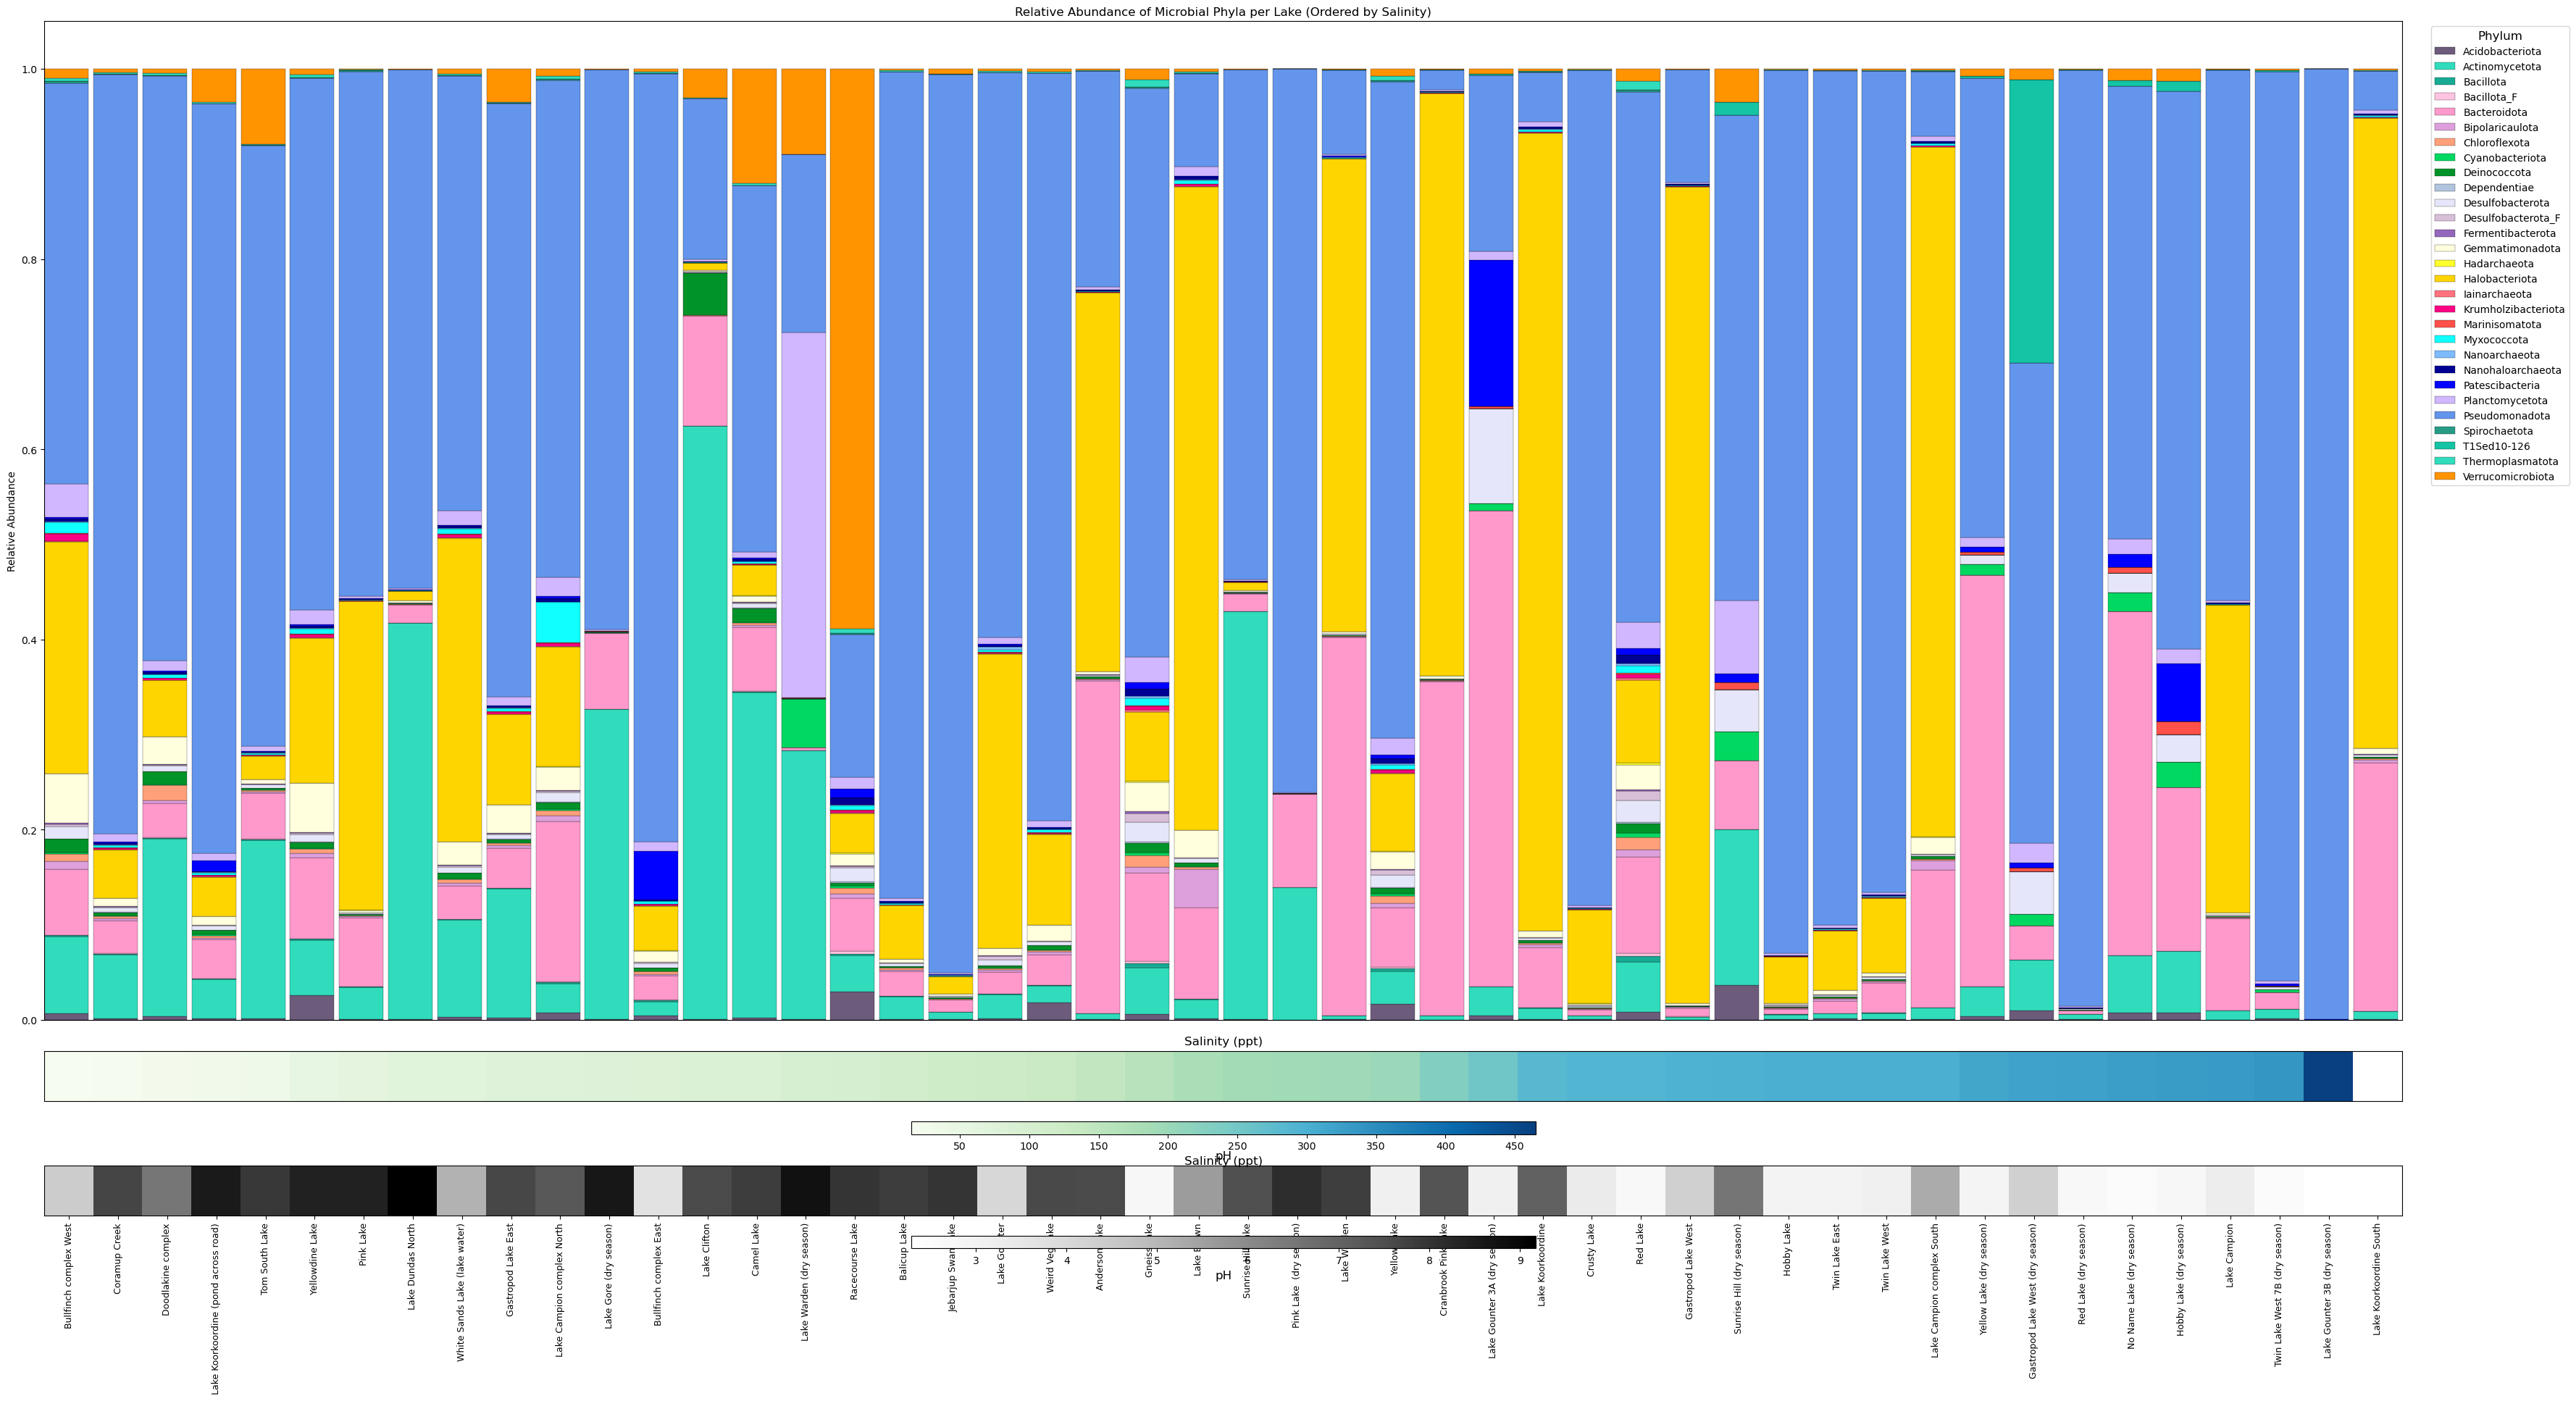

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import Normalize
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
from matplotlib.cm import get_cmap

df = wet_and_dry_merged_df.copy()
df = df.dropna(subset=["phylum", "name_full", "Abundance"])

meta_df = df.groupby("name_full", as_index=False)[["Salinity", "pH"]].mean().sort_values("Salinity")
lake_order = meta_df["name_full"].tolist()

grouped = df.groupby(["name_full", "phylum"])["Abundance"].sum().reset_index()

pivot_df = grouped.pivot(index="name_full", columns="phylum", values="Abundance").fillna(0)
pivot_df = pivot_df.loc[lake_order]  # enforce salinity-based order

pivot_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

base_palette = [
    "#6C5B7B", "#30DCBC", "#18AA93", "#FFC4E1", "#FF99CC",
    "#DDA0DD", "#FFA07A",  "#00D861","#009329", "#B0C4DE", 
    "#E6E6FA", "#D8BFD8", "#9467bd",  "#FFFFDD", "#FDFF2A",
    "#FFD500", "#FF737F", "#FF0385", "#FF5149", "#10FFFF", 
     "#7DBBFF", "#000193", "#0001FF", "#D0B7FF", "#6495EC", 
    "#269C86", "#14C4A4", "#30DCBC", "#FF9300"
]
n_phyla = pivot_df.shape[1]
fallback_colors = get_cmap("tab20").colors
colors = (base_palette + list(fallback_colors))[:n_phyla]


fig = plt.figure(figsize=(42, 22))
gs = GridSpec(3, 1, height_ratios=[6, 0.5, 0.5], hspace=0.08)

# Stacked Bar Plot
ax_bar = fig.add_subplot(gs[0])

x = np.arange(len(pivot_df))  # fixed positions
bar_width = 0.9
bottom = np.zeros(len(pivot_df))

for i, phylum in enumerate(pivot_df.columns):
    values = pivot_df[phylum].values
    ax_bar.bar(
        x=x,
        height=values,
        bottom=bottom,
        width=bar_width,
        label=phylum,
        color=colors[i],
        edgecolor="black",
        linewidth=0.2,
        align="edge"
    )
    bottom += values

ax_bar.set_xlim(0, len(pivot_df))
ax_bar.set_ylabel("Relative Abundance")
ax_bar.set_xticks([])
ax_bar.set_title("Relative Abundance of Microbial Phyla per Lake (Ordered by Salinity)")


ax_sal = fig.add_subplot(gs[1])

sal_array = np.expand_dims(meta_df["Salinity"].values, axis=0)
sal_norm = Normalize(vmin=meta_df["Salinity"].min(), vmax=meta_df["Salinity"].max())
sal_cmap = cm.get_cmap("GnBu")

ax_sal.imshow(sal_array, aspect='auto', cmap=sal_cmap, norm=sal_norm, extent=[0, len(pivot_df), 0, 1])
ax_sal.set_yticks([])
ax_sal.set_xticks([])
ax_sal.set_xlim(0, len(pivot_df))
ax_sal.set_title("Salinity (ppt)", fontsize=12)


ax_ph = fig.add_subplot(gs[2])

ph_array = np.expand_dims(meta_df["pH"].values, axis=0)
ph_norm = Normalize(vmin=meta_df["pH"].min(), vmax=meta_df["pH"].max())
ph_cmap = cm.get_cmap("Greys")

ax_ph.imshow(ph_array, aspect='auto', cmap=ph_cmap, norm=ph_norm, extent=[0, len(pivot_df), 0, 1])
ax_ph.set_yticks([])
ax_ph.set_xticks(x + 0.5)
ax_ph.set_xticklabels(lake_order, rotation=90, ha="center", fontsize=9)
ax_ph.set_xlim(0, len(pivot_df))
ax_ph.set_title("pH", fontsize=12)

sal_cb = fig.colorbar(
    cm.ScalarMappable(norm=sal_norm, cmap=sal_cmap),
    ax=ax_sal, orientation='horizontal', pad=0.25, aspect=50
)
sal_cb.set_label("Salinity (ppt)", fontsize=12)


ph_cb = fig.colorbar(
    cm.ScalarMappable(norm=ph_norm, cmap=ph_cmap),
    ax=ax_ph, orientation='horizontal', pad=0.25, aspect=50
)
ph_cb.set_label("pH", fontsize=12)

ax_bar.legend(title="Phylum", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10, title_fontsize=12)


plt.tight_layout()
plt.savefig("/Users/skoog/Desktop/stackedbar_salinity_pH_aligned_FULL_WIDTH.svg", format="svg", dpi=300)
plt.show()

## Viral family abundance

In [19]:
import os, re
import pandas as pd

def canon(x):
    x = str(x)
    if x.endswith(".faa"):
        x = x[:-4]
    return re.sub(r"_provirus_\d+_\d+$", "", x)

def clean_sample(c):
    c = re.sub(r"\s*RPKM$", "", str(c)).strip()   
    c = re.sub(r"(\.sorted)?(\.bam)?$", "", c)   
    c = re.sub(r"_sorted$", "", c)               
    return c.strip()


rpkm_wide = pd.read_csv(VIRAL_RPKM_COMBINED, sep="\t")
rpkm_wide.rename(columns={rpkm_wide.columns[0]: "contig_id"}, inplace=True)

_rpkm_cols = [c for c in rpkm_wide.columns if c == "contig_id" or "rpkm" in str(c).lower()]
if len(_rpkm_cols) > 1:
    rpkm_wide = rpkm_wide[_rpkm_cols]

rpkm_wide.columns = ["contig_id"] + [clean_sample(c) for c in rpkm_wide.columns[1:]]
rpkm_wide["contig_id"] = rpkm_wide["contig_id"].map(canon)

merged_df = rpkm_wide          

# wide -> long
viral_long = rpkm_wide.melt(id_vars=["contig_id"], var_name="sample", value_name="abundance")
viral_long = viral_long[pd.to_numeric(viral_long["abundance"], errors="coerce").ne(0)]

n_vir_rpkm = rpkm_wide["contig_id"].nunique()
n_samples  = viral_long["sample"].nunique()
print(f"[RPKM]  {n_vir_rpkm} viruses x {n_samples} samples "
      f"-> {len(viral_long):,} non-zero (virus, sample) rows")

tax = pd.read_csv(WATL_CATALOG_SUMMARY, sep="\t")
tax.rename(columns={tax.columns[0]: "contig_id"}, inplace=True)
tax["contig_id"] = tax["contig_id"].map(canon)

_levels = ["virus", "realm", "kingdom", "phylum", "class", "order", "family"]
if "taxonomy" in tax.columns:
    parts = tax["taxonomy"].str.split(";", expand=True)
    for i, lvl in enumerate(_levels):
        tax[lvl] = parts[i] if i in parts.columns else None

def _fill(row, primary, fallbacks):
    v = row.get(primary)
    if pd.notna(v) and str(v).strip():
        return v
    for lv in fallbacks:
        u = row.get(lv)
        if pd.notna(u) and str(u).strip():
            return f"Unclassified {u}"
    return "Unclassified"

if "family" in tax.columns:
    tax["family"] = tax.apply(lambda r: _fill(r, "family", ["order", "class", "phylum", "kingdom", "realm"]), axis=1)
    tax["order"]  = tax.apply(lambda r: _fill(r, "order",  ["class", "phylum", "kingdom", "realm"]), axis=1)

_tax_cols = [c for c in ["realm", "kingdom", "phylum", "class", "order", "family"] if c in tax.columns]
tax = tax[["contig_id"] + _tax_cols].drop_duplicates("contig_id")


if WATL_SAMPLE_METADATA_SHEET:
    meta = pd.read_excel(WATL_SAMPLE_METADATA, sheet_name=WATL_SAMPLE_METADATA_SHEET)
else:
    meta = pd.read_excel(WATL_SAMPLE_METADATA)

_sample_col = next((c for c in ["Sample_ID", "sample", "Sample", "sample_id"] if c in meta.columns),
                   meta.columns[0])
meta = meta.rename(columns={_sample_col: "sample"})
meta["sample"] = meta["sample"].astype(str).map(clean_sample)
if "Season" in meta.columns:
    meta["Season"] = meta["Season"].astype(str).str.strip().str.lower()
else:
    print("  !! metadata has no 'Season' column -> all rows treated as wet (no '(dry season)' columns)")

_has_sampletype = "Sample_Type" in meta.columns
_meta_keep = [c for c in ["sample", "Lake_name", "pH", "Salinity", "Season",
                          "Sample_Type"] if c in meta.columns]


watl = viral_long.merge(tax, on="contig_id", how="left")
watl = watl.merge(meta[_meta_keep], on="sample", how="left")


def _name_full(row):
    lake = row.get("Lake_name")
    if pd.isna(lake):
        return pd.NA
    return f"{lake} (dry season)" if str(row.get("Season", "")).lower() == "dry" else str(lake)
watl["name_full"] = watl.apply(_name_full, axis=1)


if not _has_sampletype:
    watl["Sample_Type"] = watl.get("Season", pd.Series(index=watl.index, dtype=object)).map(
        {"wet": "Wet Season DNA", "dry": "Dry Season DNA"}).fillna("Brine DNA")

watl["Environment"] = watl.get("Season", pd.Series(index=watl.index, dtype=object)).map(
    {"wet": "WATL wet season", "dry": "WATL dry season"})
watl["Present"] = 1


_keep = (["contig_id"] + _tax_cols
         + ["name_full", "Lake_name", "Season", "pH", "Salinity",
            "abundance", "Sample_Type", "Environment", "Present"])
_keep = [c for c in _keep if c in watl.columns]
Final_WATL_wet_dry_merged_df = watl[_keep].copy()

_n_nofam = 0
if "family" in Final_WATL_wet_dry_merged_df.columns:
    Final_WATL_wet_dry_merged_df["family"] = (
        Final_WATL_wet_dry_merged_df["family"]
        .str.replace(r"\(Caudoviricetes\)", "", regex=True).str.strip()
    )
    _n0 = len(Final_WATL_wet_dry_merged_df)
    Final_WATL_wet_dry_merged_df = Final_WATL_wet_dry_merged_df.dropna(subset=["family"])
    _n_nofam = _n0 - len(Final_WATL_wet_dry_merged_df)
else:
    print("  !! no 'family' column produced -> check WATL_CATALOG_SUMMARY has a 'taxonomy' column")

Final_WATL_wet_dry_merged_df.to_excel(FINAL_VIRAL_OUT, index=False)


_n_tax = len(set(rpkm_wide["contig_id"]) & set(tax["contig_id"]))
print("\n=== combined-catalog viral abundance — summary ===")
print(f"  viruses in RPKM matrix      : {n_vir_rpkm}")
print(f"  viruses with any taxonomy   : {_n_tax}")
if "family" in watl.columns:
    print(f"  viruses with a family       : {watl.loc[watl['family'].notna(), 'contig_id'].nunique()}")
    print(f"  (virus,sample) rows dropped (no family) : {_n_nofam:,}")
    print(f"  unique families (kept)      : {Final_WATL_wet_dry_merged_df['family'].nunique()}")

if "Season" in watl.columns:
    by_season = (watl.dropna(subset=["name_full"]).groupby("Season")
                 .agg(samples=("sample", "nunique"),
                      viruses=("contig_id", "nunique"),
                      rows=("contig_id", "size")))
    print("\n  wet/dry split (rows that matched metadata):")
    print(by_season.to_string())

_unmatched = sorted(set(viral_long["sample"]) - set(meta["sample"]))
if _unmatched:
    print(f"\n  !! {len(_unmatched)} RPKM sample(s) NOT in the metadata sheet "
          f"(no lake/pH -> they vanish from the figure):")
    print("    " + ", ".join(_unmatched[:12]) + (" ..." if len(_unmatched) > 12 else ""))

try:
    _micro_lakes = set(wet_and_dry_merged_df["name_full"].dropna().unique())
    _viral_lakes = set(Final_WATL_wet_dry_merged_df["name_full"].dropna().unique())
    _viral_only  = sorted(_viral_lakes - _micro_lakes)
    _micro_only  = sorted(_micro_lakes - _viral_lakes)
    print("\n  lake-name alignment with microbial panels:")
    print(f"    shared lake columns : {len(_viral_lakes & _micro_lakes)}")
    if _viral_only:
        print(f"    viral-only (no microbial col -> dropped by lake_order): {_viral_only}")
    if _micro_only:
        print(f"    microbial-only (empty/white viral column)            : {_micro_only}")
    if not _viral_only and not _micro_only:
        print("    all lake names match.")
except NameError:
    print("\n  (run the microbial cells above first for the lake-name alignment check)")


[RPKM]  11370 viruses x 66 samples -> 15,907 non-zero (virus, sample) rows


/var/folders/cy/8q3xnh8d03z1c1c21dpxp6380000gn/T/ipykernel_92534/1038734606.py:58: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  tax = pd.read_csv(WATL_CATALOG_SUMMARY, sep="\t")
/var/folders/cy/8q3xnh8d03z1c1c21dpxp6380000gn/T/ipykernel_92534/1038734606.py:155: UserWarning: Pandas requires version '1.4.3' or newer of 'xlsxwriter' (version '1.3.8' currently installed).
  Final_WATL_wet_dry_merged_df.to_excel(FINAL_VIRAL_OUT, index=False)



=== combined-catalog viral abundance — summary ===
  viruses in RPKM matrix      : 11370
  viruses with any taxonomy   : 11370
  viruses with a family       : 9610
  (virus,sample) rows dropped (no family) : 0
  unique families (kept)      : 62

  wet/dry split (rows that matched metadata):
        samples  viruses   rows
Season                         
dry          18     3194   3747
wet          48     7376  12160

  lake-name alignment with microbial panels:
    shared lake columns : 47
    microbial-only (empty/white viral column)            : ['Gneiss Lake', 'Lake Gounter 3C (dry season)']


In [20]:
merged_df.head()

,contig_id,220804_BK_C1_DNA_brine_C,220805_BK_F1_DNA_brine,220805_BK_F3_DNA_brine_C,220805_MW_S1_DNA_Brine,220805_MW_S2_DNA_Brine_B,220805_MW_S3_DNA_Brine,220805_MW_S4_DNA_Brine,220806_BK_F5_DNA_brine_A,220806_BK_F6D_DNA_brine,...,240114_N9_DNA_S11_L001,240114_N9_DNA_S22_L002,240115_N10_DNA_S12_L001,240115_N10_DNA_S23_L002,240116_N11_DNA_S13_L001,240116_N12_DNA_S14_L001,240116_N13_DNA_S15_L001,240117_N15_DNA_S17_L001,240117_N15_DNA_S28_L002,240120_N3C_DNA_S5_L001
0,WATLvirus_00000031,3729.2432,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,WATLvirus_00000043,3301.0012,0.0,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,WATLvirus_00003595,0.0000,0.0,829.9422,0.0000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,WATLvirus_00003601,0.0000,0.0,1933.3817,0.0000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,WATLvirus_00004265,0.0000,0.0,0.0000,2602.8872,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [21]:
# number of unique bins
num_unique_bins = Final_WATL_wet_dry_merged_df["family"].nunique()
print("Number of unique family:", num_unique_bins)


Number of unique family: 62


In [ ]:
display(Final_WATL_wet_dry_merged_df)

/var/folders/cy/8q3xnh8d03z1c1c21dpxp6380000gn/T/ipykernel_92534/1972653301.py:140: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. In future versions, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = copy.copy(mpl.cm.get_cmap("BuPu"))
  cmap.set_bad("white")
/var/folders/cy/8q3xnh8d03z1c1c21dpxp6380000gn/T/ipykernel_92534/1972653301.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


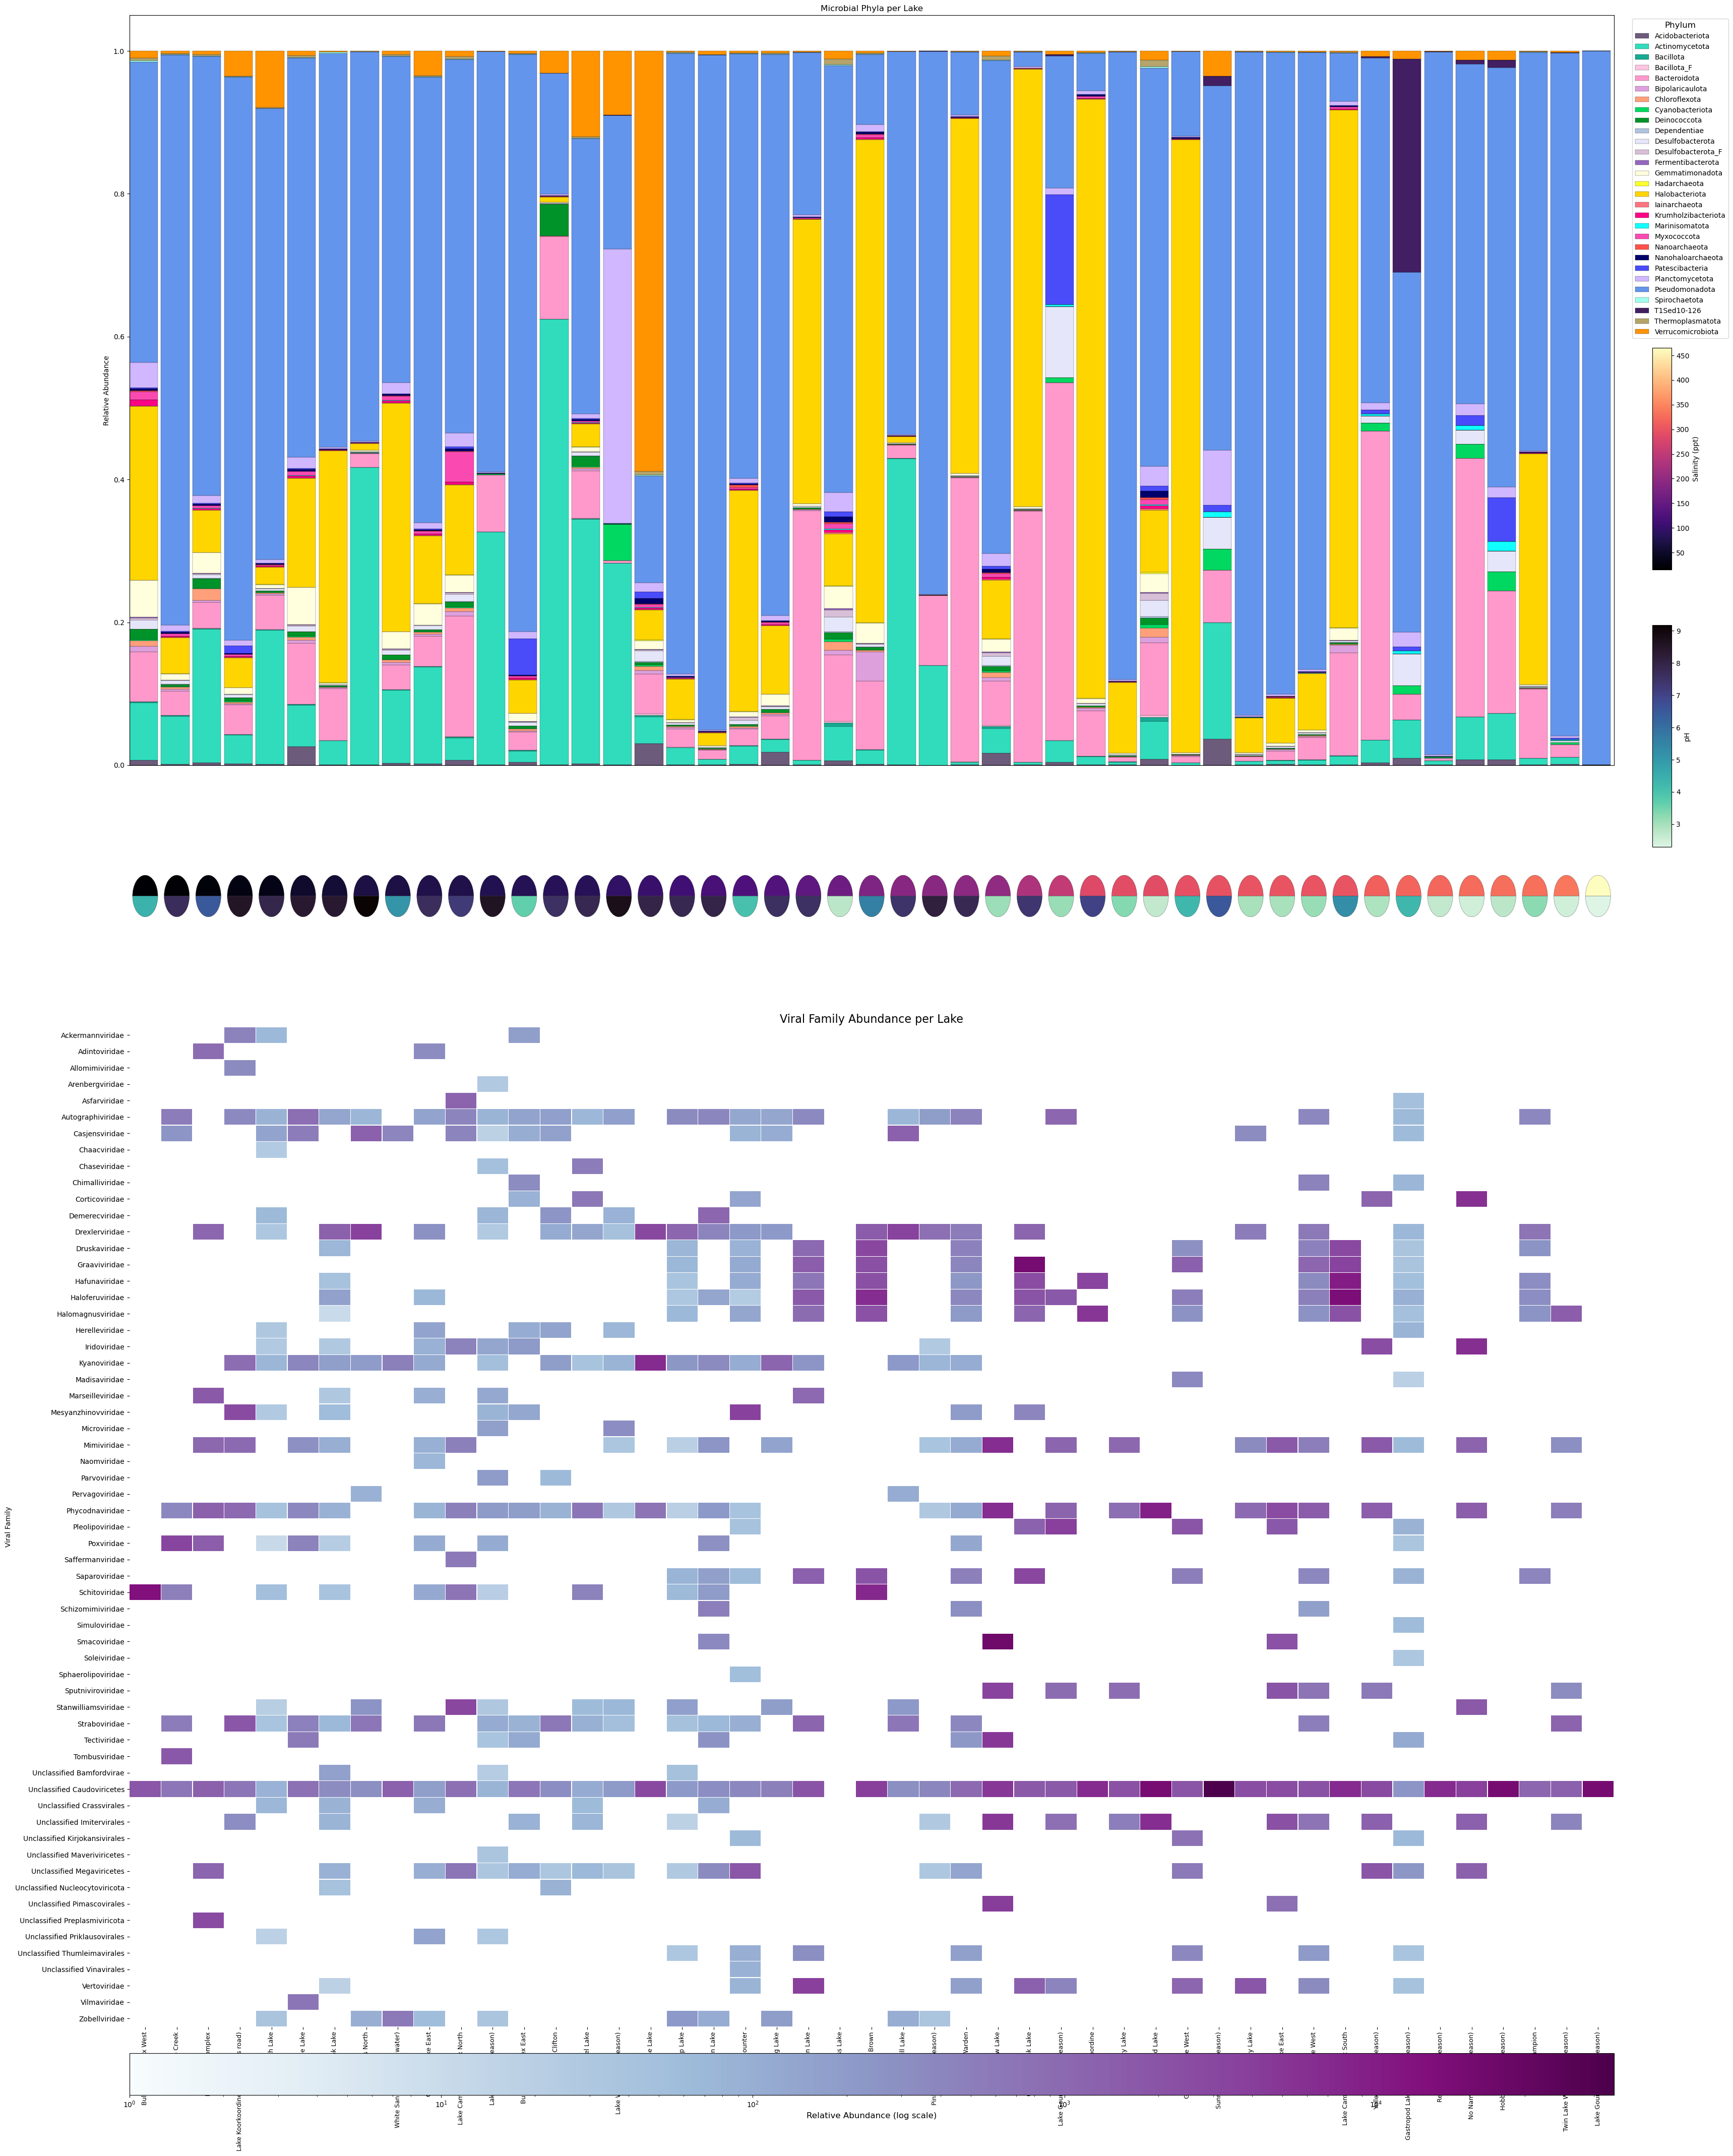

In [22]:
#combine figures
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm, Normalize
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
from matplotlib.cm import get_cmap
from matplotlib.patches import Wedge

df_viral = Final_WATL_wet_dry_merged_df.copy()
df_viral = df_viral[~df_viral["name_full"].isin(["Lake Koorkoordine South"]) & df_viral["name_full"].notna()]
df_viral = df_viral[~df_viral["family"].isin(["Unclassified"])]
exclude_types = ["MAT VIROME", "MAT DNA", "SEDIMENT DNA", "GROUNDWATER DNA", "GROUNDWATER VIROME", "VIROME"]
df_viral = df_viral[~df_viral["Sample_Type"].isin(exclude_types)]
df_viral["family"] = df_viral["family"].str.strip().str.title()
df_viral["name_full"] = df_viral["name_full"].str.strip()
df_viral["abundance"] = df_viral["abundance"].fillna(1)

df_phylum = wet_and_dry_merged_df.copy()
df_phylum = df_phylum.dropna(subset=["phylum", "name_full", "Abundance"])


meta = (
    df_phylum.dropna(subset=["Salinity"])
    .groupby("name_full")[["Salinity", "pH"]]
    .mean()
    .reset_index()
    .sort_values("Salinity")
)
meta = meta[meta["name_full"] != "Lake Koorkoordine South"].reset_index(drop=True)
lake_order = meta["name_full"].tolist()
sal_array = np.expand_dims(meta["Salinity"].values, axis=0)
ph_array = np.expand_dims(meta["pH"].values, axis=0)


grouped_viral = df_viral.groupby(["family", "name_full"])["abundance"].mean().reset_index()
all_families = sorted(df_viral["family"].dropna().unique())
heatmap = (
    grouped_viral.pivot(index="family", columns="name_full", values="abundance")
    .reindex(index=all_families, columns=lake_order)
)

grouped_phylum = df_phylum.groupby(["name_full", "phylum"])["Abundance"].sum().reset_index()
pivot_df = grouped_phylum.pivot(index="name_full", columns="phylum", values="Abundance").fillna(0)
pivot_df = pivot_df.loc[lake_order]
pivot_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)


base_palette = [
    "#6C5B7B", "#30DCBC", "#18AA93", "#FFC4E1", "#FF99CC",
    "#DDA0DD", "#FFA07A", "#00D861", "#009329", "#B0C4DE", 
    "#E6E6FA", "#D8BFD8", "#9467bd", "#FFFFDD", "#FDFF2A",
    "#FFD500", "#FF737F", "#FF0385", "#10FFFF",   
    "#FA4AB2", "#FF5149", "#00016B", "#4A4CFA", "#D0B7FF", "#6495EC", 
    "#A2FFEE", "#421F62", "#B5A46C", "#FF9300"
]
n_phyla = pivot_df.shape[1]
fallback_colors = get_cmap("tab20").colors
colors = (base_palette + list(fallback_colors))[:n_phyla]


fig = plt.figure(figsize=(38, 55))
#gs = GridSpec(nrows=6, ncols=1, height_ratios=[9, 1, 12, 0.5, 0.01, 0.01], hspace=0.08)
gs = GridSpec(nrows=6, ncols=1, height_ratios=[9, 2.5, 12, 0.5, 0.01, 0.01], hspace=0.08)


ax_bar = fig.add_subplot(gs[0])
x = np.arange(len(pivot_df))
bar_width = 0.9
bottom = np.zeros(len(pivot_df))

for i, phylum in enumerate(pivot_df.columns):
    values = pivot_df[phylum].values
    ax_bar.bar(
        x=x,
        height=values,
        bottom=bottom,
        width=bar_width,
        label=phylum,
        color=colors[i],
        edgecolor="black",
        linewidth=0.2,
        align="edge"
    )
    bottom += values

ax_bar.set_xlim(0, len(pivot_df))
ax_bar.set_ylabel("Relative Abundance")
ax_bar.set_xticks([])
ax_bar.set_title("Microbial Phyla per Lake")


# Halfcircles for Salinity & pH

ax_circles = fig.add_subplot(gs[1])
ax_circles.set_xlim(0, len(lake_order))
ax_circles.set_ylim(-2, 2)

ax_circles.axis("off")

sal_norm = Normalize(vmin=meta["Salinity"].min(), vmax=meta["Salinity"].max())
ph_norm = Normalize(vmin=meta["pH"].min(), vmax=meta["pH"].max())
sal_cmap = cm.get_cmap("magma")
ph_cmap = cm.get_cmap("mako_r")
radius = 0.4

for i, lake in enumerate(lake_order):
    sal = meta.loc[meta["name_full"] == lake, "Salinity"].values[0]
    ph = meta.loc[meta["name_full"] == lake, "pH"].values[0]
    wedge_top = Wedge((i + 0.5, 0), radius, 0, 180, facecolor=sal_cmap(sal_norm(sal)), edgecolor="black", lw=0.2)
    wedge_bottom = Wedge((i + 0.5, 0), radius, 180, 360, facecolor=ph_cmap(ph_norm(ph)), edgecolor="black", lw=0.2)
    ax_circles.add_patch(wedge_top)
    ax_circles.add_patch(wedge_bottom)

# Viral Family Heatmap
ax_hm = fig.add_subplot(gs[2])
vmax_val = np.nanmax(heatmap.values)
norm = LogNorm(vmin=1, vmax=vmax_val)
import copy
cmap = copy.deepcopy(plt.cm.BuPu)
cmap.set_bad("white")

sns.heatmap(
    heatmap,
    ax=ax_hm,
    cmap=cmap,
    norm=norm,
    cbar=False,
    linewidths=0.2
)
ax_hm.set_title("Viral Family Abundance per Lake", fontsize=16)
ax_hm.set_ylabel("Viral Family")
ax_hm.set_xlabel("")
ax_hm.set_xticks(x + 0.5)
ax_hm.set_xticklabels(lake_order, rotation=90, ha="center", fontsize=9)


ax_cb = fig.add_subplot(gs[3])
cb = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=ax_cb, orientation='horizontal')
cb.set_label("Relative Abundance (log scale)", fontsize=12)


sal_cbar_ax = fig.add_axes([0.92, 0.68, 0.01, 0.08])
fig.colorbar(cm.ScalarMappable(norm=sal_norm, cmap=sal_cmap), cax=sal_cbar_ax).set_label("Salinity (ppt)")

ph_cbar_ax = fig.add_axes([0.92, 0.58, 0.01, 0.08])
fig.colorbar(cm.ScalarMappable(norm=ph_norm, cmap=ph_cmap), cax=ph_cbar_ax).set_label("pH")

ax_bar.legend(title="Phylum", bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.savefig("/Users/skoog/Desktop/FLIPPED_microbial_above_viral_abundance_HALF_CIRCLES2.svg", format="svg", dpi=300)
plt.show()